In [1]:
import os
from pyscf import gto
from pyscf.dft import numint
from pyscf.lib import param
from datetime import datetime

import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.utils.grids import cubical_grid, cubical_sampling, \
     CubicalGrid, spherical_grid, spherical_radial_sampling
import equiv_dens.utils.base as utils
import equiv_dens.utils.orbitals as orbitals
from equiv_dens.utils.misc import generate_id

from functools import partial
from argparse import Namespace
from equiv_dens.training import density_errors
import matplotlib.pyplot as plt
import numpy as np
from equiv_dens.training import model_loader

%load_ext autoreload
%autoreload 2
%cd /home/mihail/Documents/workspace/equiv_dens/

/home/mihail/Documents/workspace/equiv_dens


In [16]:
main_args = Namespace()

# main_args.args_file = "args/resorcinol_all_001.txt"
main_args.args_file = "args/ethanethiol_all_006_test.txt"
# main_args.args_file = "args/ethanethiol_df_coeffs_001_test.txt"
main_args.ref_np_load_file = None
main_args.ref_dens_load_file = None
main_args.res_load_file = 'datasets/ethanethiol_all_006_test.pt'
main_args.save_file = 'ethanethiol_all_006'
# main_args.res_load_file = 'datasets/resorcinol_all_005_test.pt'
# main_args.save_file = 'resorcinol_all_005'
# main_args.res_load_file = 'datasets/ethanethiol_df_coeffs_001_test.pt'
# main_args.save_file = 'ethanethiol_df_coeffs_001'
main_args.df_error = True
main_args.use_gpu = False
main_args.num_samples = 100
main_args.make_plots = True

df_losses = None

In [3]:
args, hyperparam_args = parse_command_line_arguments(arg_file=main_args.args_file)

# print('type dtype', type(args.dtype))
args.fix_arguments = True
# print('args np dir', args.np_dataset)
# args.restart = None
# args.pred_radial_coeffs = False

if args.restart is None:
    # generate "unique" id for the run (very unlikely that two runs will have the same ID)
    model_code = generate_id()
    directory = os.path.join(args.save_dir, datetime.utcnow().strftime("%Y-%m-%d_") +
                             model_code)  # generate directory name
    # create directories
    # if not os.path.exists(directory):
    #     os.makedirs(directory)
    # # write command line arguments to file (useful for reproducibility)
    # with open(os.path.join(directory, 'args.txt'), 'w') as f:
    #     for key in args.__dict__.keys():
    #         # special case for list input
    #         if isinstance(args.__dict__[key], list):
    #             for entry in args.__dict__[key]:
    #                 f.write('--' + key + '=' + str(entry) + "\n")
    #         else:
    #             f.write('--' + key + '=' + str(args.__dict__[key]) + "\n")
    checkpoint = None
    latest_checkpoint = 0
    step = 0
    restore = False
    data_split_indices = None
    # restarts run from latest checkpoint
else:
    # no restart directory specifie
    directory = args.restart
    # load latest checkpoint
    checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
    checkpoint = torch.load(os.path.join(
        checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
    latest_checkpoint = checkpoint['step']
    model_code = checkpoint['ID']  # load ID
    step = checkpoint['step']
    for arg in vars(checkpoint['args']):
        if args.fix_arguments:
            if arg in hyperparam_args:
                # print('loading hyperparam arg', arg)
                setattr(args, arg, getattr(checkpoint['args'], arg))
        else:
            # print('loading all arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    restore = True
    data_split_indices = checkpoint['data_split_indices']

args.df_weight = 1.0

print('model code:', model_code)

# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False

# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.verbose = 0
args.use_gpu = False
print('args use gpu', args.use_gpu)
args.cube_grid = False
args.radii_adjust = True
args.expansion_constraint = None
if args.cube_grid:
    args.cube_origin = -0.25
    args.cube_extent = 0.5
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    args.spherical_grid_level = 1
    grid_fn = partial(spherical_grid, level=args.spherical_grid_level)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None
    rotate = False

required_properties = ['energy', 'forces', 'df_coeffs', 'density', 'dipole_moment']

if main_args.ref_np_load_file is not None:
    args.np_dataset_test = main_args.ref_np_load_file
if main_args.ref_dens_load_file is not None:
    args.dens_dataset_test = main_args.ref_dens_load_file

dataset = AtomsDensityData(np_path=args.np_dataset_test, density_path=args.dens_dataset_test,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000000000000000,
                           required_properties=required_properties,
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=grid_fn,
                           pyscf_grid=args.pyscf_grid,
                           pyscf_rotate=rotate,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           cutoff=args.cutoff,
                           df_loss_weights=args.df_loss_weights,
                           projected_density=args.projected_density,
                           )
print('dataset length', len(dataset))
print('sample pos shape', dataset.get_properties([0])['positions'].shape)
print('sample dens shape', dataset.get_properties([0])['density'].shape)
if main_args.num_samples < 1:
    main_args_num_samples = len(dataset)
print('num samples', main_args.num_samples)
print('args use gpu', args.use_gpu)

model code: BSJc2pPA
args use gpu True
loading density fromdatasets/ethanethiol_combo_Aidx-1000_pyscf_augccpvdz.npy...
loading atoms fromdatasets/ethanethiol_combo_Aidx-1000.npy...
args use gpu False
finished init
dataset length 1000
sample pos shape torch.Size([1, 9, 3])
sample dens shape torch.Size([1, 31460])
num samples 100
args use gpu False


/home/mihail/Documents/workspace/equiv_dens/src/equiv_dens/utils/base.py:487: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /opt/conda/conda-bld/pytorch_1678402411778/work/aten/src/ATen/native/TensorCompare.cpp:493.)
  num_repeats = torch.where(pbc, num_repeats, torch.zeros_like(num_repeats))


In [19]:
df_losses = None
if main_args.df_error:
    # df_losses = {'dens_mae': [], 'dens_rmse': [], 'dpm_mae': [],
    #              'dpm_rmse': [], 'kl_loss': [],
    #              'dpm_mag': [], 'dpm_ang': [], 'lda_mae': [],
    #              'coulomb': [], 'coulomb_int': [], 'mae_23': [], 'mae_43': [],
    #              'lda_23_mae': [], 'dpm_coord_rmse': [],
    #              'dpm_pos_coord_rmse': [], 'dpm_neg_coord_rmse': [],
    #              'dpm_int_rmse': []}

    dataset_df = AtomsDensityData(np_path=args.np_dataset_test, density_path=args.dens_dataset_test,
                                  orbitals_path=args.orbitals_file,
                                  density_n_samp=10000000000000000000000,
                                  required_properties=required_properties,
                                  center_positions=False,
                                  radial_coeffs_file=args.radial_coeffs_file,
                                  dtype=args.dtype,
                                  grid_fn=grid_fn,
                                  pyscf_grid=args.pyscf_grid,
                                  pyscf_rotate=rotate,
                                  sampling_fn=sampling_fn,
                                  grid_extent=grid_extent,
                                  grid_origin=grid_origin,
                                  cutoff=args.cutoff,
                                  df_loss_weights=args.df_loss_weights,
                                  projected_density=True,
                                  )

finished init


In [20]:
model = model_loader.load_model(args, dataset)
idx = 1
samp = dataset.get_properties([idx])
samp_df = dataset_df.get_properties([idx])

res = model(samp)

print('samp df_coeffs', samp_df['df_coeffs'].shape)
print('res df_coeffs', res['df_coeffs'].shape)

# print('res_radial width', res['radial_width'])
# print('dataset radial coeffs', dataset.radial_coeffs)
print('res density integral', torch.sum(res['density'] * res['coord_weights'], dim=1))

cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in hartree
args energy_unit_out kcal
conversions in <function hartree_to_kcal at 0x7fd5bf916290>
conversions out <function kcal_to_kcal at 0x7fd5bf9164d0>
self.pred_radial_coeffs True
density_weight 1.0
dipole_moment_weight 1.0
force props []
no force props ['density', 'dipole_moment']
[]
samp df_coeffs torch.Size([1, 924])
res df_coeffs torch.Size([1, 924])
res density integral tensor([33.9990], grad_fn=<SumBackward1>)


In [25]:
center_of_mass = torch.sum(samp['batch_positions'] * samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)\
        / torch.sum(samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)

distance_from_com = torch.norm(samp['coords'] - center_of_mass, dim=2)

density_mae = torch.sum(torch.abs(samp['density'] - res['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
density_err = torch.abs(samp['density'] - res['density']) * samp['coord_weights']
res = orbitals.calc_dipole_moment(res)
dpm_err = torch.norm(samp['dipole_moment'] - res['dipole_moment'])
# dpm_point_err = density_errors.dipole_pointwise_int_loss(res['density'], samp['density'], samp['coords'], samp['coord_weights'])
dpm_point_err = ((res['density'] - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)

print('density_mae', density_mae)
print('dpm norm error', dpm_err)
print('dpm pointwise error', dpm_point_err.sum())

density_mae tensor(0.0012, grad_fn=<DivBackward0>)
dpm norm error tensor(0.0066, grad_fn=<LinalgVectorNormBackward0>)
dpm pointwise error tensor(0.0075, grad_fn=<SumBackward0>)


In [26]:
density_df_mae = torch.sum(torch.abs(samp['density'] - samp_df['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
density_df_err = torch.abs(samp['density'] - samp_df['density']) * samp['coord_weights']
dpm_df_err = torch.norm(samp['dipole_moment'] - samp_df['dipole_moment'])
# dpm_df_point_err = density_errors.dipole_pointwise_int_loss(samp_df['density'], samp['density'], samp['coords'], samp['coord_weights'])
dpm_df_point_err = ((samp_df['density'] - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)
print('density_df_mae', density_df_mae)
print('dpm df norm error', dpm_df_err)
print('dpm df pointwise error', dpm_df_point_err.sum())

density_df_mae tensor(0.0051)
dpm df norm error tensor(0.0022)
dpm df pointwise error tensor(0.0019)


In [27]:
dcom = distance_from_com.detach().cpu().numpy().flatten()
dist_com_idx = np.argsort(dcom)
dist_com = dcom[dist_com_idx]

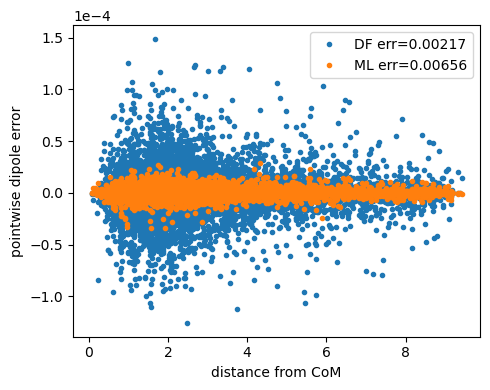

tensor(0.0075, grad_fn=<SumBackward0>)
tensor(0.0019)


In [52]:
fig = plt.figure(figsize=(5, 4))
plt.ticklabel_format(style='sci', axis='y')
plt.plot(dcom, dpm_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='DF err={:.5f}'.format(dpm_err), marker='.', linestyle='none')
plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML err={:.5f}'.format(dpm_err), marker='.', linestyle='none')
plt.xlabel('distance from CoM')
plt.ylabel('pointwise dipole error')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.tight_layout()
plt.savefig('figures/pointwise_dipole_error_df.png', dpi=300)
plt.show()
print(torch.sum(dpm_point_err))
print(torch.sum(dpm_df_point_err))

In [34]:
basis = 'augccpvdz'
auxbasis = 'augccpvqzjkfit'
ml_df_coeffs, auxmol_ext = orbitals.ml_basis_to_df_coeffs(res, basis, auxbasis)
dens = orbitals.sample_projected_density(samp, torch.tensor(ml_df_coeffs).unsqueeze(0),
                                         dataset_df, auxmol=auxmol_ext)
print(samp['atom_numbers'])

print('sum projected density', torch.sum(samp['density'] * samp['coord_weights']))
print('sum true density', torch.sum(dens * samp['coord_weights']))
print('projected density error', torch.sum(torch.abs(dens - samp['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers']))
samp2 = dataset.get_properties([idx])
dpm = orbitals.calc_dipole_moment(samp2, density=dens)['dipole_moment']
print('dipole moment error', 4.8 * torch.norm(dpm - samp['dipole_moment']))

converged SCF energy = -477.717521395218
9
9
auxmol_ext env [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  3.37362220e+00 -3.72008090e+00  3.49313984e+00  0.00000000e+00
  1.87463104e+00 -1.24938867e+00  1.78240667e+00  0.00000000e+00
  4.89542811e+00 -4.02209866e+00 -1.03630877e+00  0.00000000e+00
  3.35319243e+00 -6.64996886e+00  1.85272522e-01  0.00000000e+00
  1.75401542e+00 -4.33301717e+00 -2.05509784e+00  0.00000000e+00
  4.17601119e-01 -7.33562751e+00  2.57129359e+00  0.00000000e+00
  2.06745676e+00 -3.40270899e+00  1.88105796e+00  0.00000000e+00
  3.09747096e+00 -4.63007464e+00 -4.32293756e-01  0.00000000e+00
 -6.75711271e-01 -4.98855187e+00  2.99480959e+00  0.00000000e+00
  1.65977893e+03  4.68722412e+

In [38]:
density_ml_df_mae = torch.sum(torch.abs(samp['density'] - dens) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
density_ml_df_err = torch.abs(samp['density'] - dens) * samp['coord_weights']
dpm_ml_df_err = torch.norm(samp['dipole_moment'] - dpm)
# dpm_df_point_err = density_errors.dipole_pointwise_int_loss(samp_df['density'], samp['density'], samp['coords'], samp['coord_weights'])
dpm_ml_df_point_err = ((dens - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)
print('density_ml_df_mae', density_ml_df_mae)
print('dpm ml df norm error', dpm_ml_df_err)
print('dpm ml df pointwise error', dpm_ml_df_point_err.sum())

density_ml_df_mae tensor(0.0010, dtype=torch.float64)
dpm ml df norm error tensor(0.0001, dtype=torch.float64)
dpm ml df pointwise error tensor(-6.5471e-05, dtype=torch.float64)


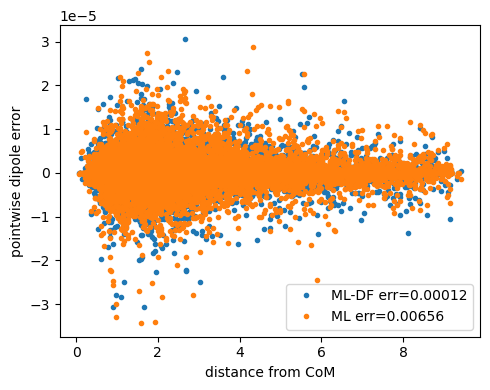

tensor(0.0075, grad_fn=<SumBackward0>)
tensor(-6.5471e-05, dtype=torch.float64)


In [53]:
fig = plt.figure(figsize=(5, 4))
plt.plot(dcom, dpm_ml_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML-DF err={:.5f}'.format(dpm_ml_df_err), marker='.', linestyle='none')
plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML err={:.5f}'.format(dpm_err), marker='.', linestyle='none')
plt.xlabel('distance from CoM')
plt.ylabel('pointwise dipole error')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/pointwise_dipole_error_ml_df.png', dpi=300)
plt.show()
print(torch.sum(dpm_point_err))
print(torch.sum(dpm_ml_df_point_err))

In [7]:
def expand_df_density_by_degree(samp_df, eval_degrees, orbital_basis, orbital_basis_size, auxbasis, auxmol=None):
    df_coeffs = samp_df['df_coeffs']
    atom = [(int(samp_df['batch_atom_numbers'][0, i].detach().cpu().numpy()),
            samp_df['batch_positions'][0, i].detach().cpu().numpy())
            for i in range(samp_df['batch_positions'].shape[1])]
    df_coeffs_split = orbitals.split_df_coeffs(atom, df_coeffs.squeeze(), dataset_df.orbital_basis_size)
    orbital_dict = orbitals.combine_orbital_basis(dataset.orbital_basis_num, 5)[0]

    masks_pos = {key: 0 for key in dataset.orbital_basis_size}
    max_orbitals = orbital_dict[16]
    masks = {}
    for z, atom_coeffs in df_coeffs_split:
        if z not in masks:
            masks[z] = torch.zeros_like(torch.tensor(atom_coeffs))
    # print('max orbitals', max_orbitals)
    for L in range(max(eval_degrees) + 1):
        nc = 2 * L + 1
        max_coeffs = max_orbitals[L][1]
        for i in range(1, max_coeffs + 1):
            for z in masks_pos.keys():
                if L >= len(orbital_dict[z]) or i >= orbital_dict[z][L][1] + 1:
                    continue
                if L in eval_degrees:
                    masks[z][masks_pos[z]:masks_pos[z] + nc] = 1
                masks_pos[z] += nc
                # print('L', L, 'max coeffs', max_coeffs, 'i', i, 'z', z, 'masks_pos', masks_pos[z])

    mask_coeffs = []
    for z, atom_coeffs in df_coeffs_split:
        atom_coeffs = torch.Tensor(atom_coeffs)
        mask_coeffs.append(atom_coeffs * masks[z])

    coeffs = torch.cat(mask_coeffs).unsqueeze(0)
    dens = orbitals.sample_projected_density(samp_df, coeffs, auxbasis, auxmol)
    new_samp = {key: samp_df[key] for key in samp_df.keys()}
    new_samp['density'] = dens

    return dens

In [8]:
orbital_basis = dataset_df.orbital_basis_num
orbital_basis_size = dataset_df.orbital_basis_size
auxbasis = dataset_df.density_fitting['auxbasis']
eval_L = [0, 1, 2, 3, 4, 5]
for i in range(len(eval_L)):
    dens_df = expand_df_density_by_degree(samp_df, eval_L[:i + 1], orbital_basis, orbital_basis_size, auxbasis)
    print('evaluated orders', eval_L[:i + 1], 'df expansion error', torch.sum(torch.abs(samp_df['density'] - dens_df) * samp_df['coord_weights']) / torch.sum(samp_df['atom_numbers']))

/tmp/ipykernel_3574937/2255313854.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  masks[z] = torch.zeros_like(torch.tensor(atom_coeffs))


evaluated orders [0] df expansion error tensor(0.1375, dtype=torch.float64)
evaluated orders [0, 1] df expansion error tensor(0.0915, dtype=torch.float64)
evaluated orders [0, 1, 2] df expansion error tensor(0.0518, dtype=torch.float64)
evaluated orders [0, 1, 2, 3] df expansion error tensor(0.0189, dtype=torch.float64)
evaluated orders [0, 1, 2, 3, 4] df expansion error tensor(0.0081, dtype=torch.float64)
evaluated orders [0, 1, 2, 3, 4, 5] df expansion error tensor(2.1513e-07, dtype=torch.float64)


In [ ]:
samps = np.random.randint(0, len(dataset), 10)
all_ml_dens_errors = []
all_df_dens_errors = []
all_ml_df_dens_errors = []
all_ml_dpm_errors = []
all_df_dpm_errors = []
all_ml_df_dpm_errors = []

all_ml_dens_mae = []
all_df_dens_mae = []
all_ml_df_dens_mae = []
all_ml_dpm_errnorm = []
all_df_dpm_errnorm = []
all_ml_df_dpm_errnorm = []
for idx in samps:
    # idx = 4
    samp = dataset.get_properties([idx])
    samp_df = dataset_df.get_properties([idx])
    res = model(samp)

    orbital_basis = dataset_df.orbital_basis_num
    orbital_basis_size = dataset_df.orbital_basis_size
    auxbasis = dataset_df.density_fitting['auxbasis']
    basis = 'augccpvdz'
    ml_df_coeffs, auxmol_ext = orbitals.ml_basis_to_df_coeffs(res, basis, auxbasis)
    eval_L = [0, 1, 2, 3, 4, 5]

    all_ml_dens_errors.append([])
    all_df_dens_errors.append([])
    all_ml_df_dens_errors.append([])
    all_ml_dpm_errors.append([])
    all_df_dpm_errors.append([])
    all_ml_df_dpm_errors.append([])

    all_ml_dens_mae.append([])
    all_df_dens_mae.append([])
    all_ml_df_dens_mae.append([])
    all_ml_dpm_errnorm.append([])
    all_df_dpm_errnorm.append([])
    all_ml_df_dpm_errnorm.append([])

    center_of_mass = torch.sum(samp['batch_positions'] * samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)\
        / torch.sum(samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)

    for i in range(len(eval_L)):
        dens_df = expand_df_density_by_degree(samp_df, eval_L[:i + 1], orbital_basis, orbital_basis_size, auxbasis)
        res = model.property_models['density'](res, eval_L=eval_L[:i + 1])
        dpm = orbitals.calc_dipole_moment(res, normalize_density=False, positive_density=False)['dipole_moment']

        samp_ml_df = {key: samp_df[key] for key in samp_df.keys()}
        print('samp_df df coeffs', samp_df['df_coeffs'].shape)
        print('ml-df df coeffs', ml_df_coeffs.shape)
        samp_ml_df['df_coeffs'] = torch.tensor(ml_df_coeffs).unsqueeze(0)
        # sph_coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': torch.tensor(ml_df_coeffs).unsqueeze(0)}, orbital_basis, samp['atom_numbers'], radial_coeffs=False, convert_to_equiv_dens=True)
        # res_df['spherical_coeffs'] = sph_coeffs['spherical_coeffs']
        # res_df = model.property_models['density'](res_df, eval_L=eval_L[:i + 1])
        dens_ml_df = expand_df_density_by_degree(samp_ml_df, eval_L[:i + 1], orbital_basis, orbital_basis_size, auxbasis, auxmol_ext)
        dpm_ml_df = orbitals.calc_dipole_moment(samp_ml_df, density=dens_ml_df, normalize_density=False, positive_density=False)['dipole_moment']

        dpm_df = orbitals.calc_dipole_moment(samp_df, density=dens_df, normalize_density=False, positive_density=False)['dipole_moment']

        # calculate pointwise density errors
        df_dens_error = (samp['density'] - dens_df) * samp['coord_weights']
        ml_dens_error = (samp['density'] - res['density']) * samp['coord_weights']
        ml_df_dens_error = (samp['density'] - dens_ml_df) * samp['coord_weights']

        # calclate density MAE
        df_dens_mae = float(torch.sum(torch.abs(samp['density'] - dens_df) * samp['coord_weights']) / torch.sum(samp['atom_numbers']))
        ml_dens_mae = float(torch.sum(torch.abs(samp['density'] - res['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers']))
        ml_df_dens_mae = float(torch.sum(torch.abs(samp['density'] - dens_ml_df) * samp['coord_weights']) / torch.sum(samp['atom_numbers']))

        # calculate pointwise dipole moment errors
        df_dpm_error = df_dens_error.unsqueeze(-1) * (samp['coords'] - center_of_mass)
        ml_dpm_error = ml_dens_error.unsqueeze(-1) * (samp['coords'] - center_of_mass)
        ml_df_dpm_error = ml_df_dens_error.unsqueeze(-1) * (samp['coords'] - center_of_mass)

        print(df_dpm_error.shape)

        # calculate dipole moment error norms
        df_dpm_errnorm = float(torch.norm(torch.sum(df_dpm_error, dim=1).squeeze()))
        ml_dpm_errnorm = float(torch.norm(torch.sum(ml_dpm_error, dim=1).squeeze()))
        ml_df_dpm_errnorm = float(torch.norm(torch.sum(ml_df_dpm_error, dim=1).squeeze()))

        print('evaluated orders', eval_L[:i + 1])
        print('df expansion error', df_dens_mae)
        print('ml expansion error', ml_dens_mae)
        print('ml-df expansion error', ml_df_dens_mae)

        print('')
        print('df dpm error', df_dpm_errnorm)
        print('ml dpm error', ml_dpm_errnorm)
        print('ml-df dpm error', ml_df_dpm_errnorm)
        print('\n')

        all_ml_dens_errors[-1].append(ml_dens_error.detach().cpu().numpy())
        all_df_dens_errors[-1].append(df_dens_error.detach().cpu().numpy())
        all_ml_df_dens_errors[-1].append(ml_df_dens_error.detach().cpu().numpy())
        all_ml_dpm_errors[-1].append(ml_dpm_error.detach().cpu().numpy())
        all_df_dpm_errors[-1].append(df_dpm_error.detach().cpu().numpy())
        all_ml_df_dpm_errors[-1].append(ml_df_dpm_error.detach().cpu().numpy())

        all_ml_dens_mae[-1].append(float(ml_dens_mae))
        all_df_dens_mae[-1].append(float(df_dens_mae))
        all_ml_df_dens_mae[-1].append(float(ml_df_dens_mae))
        all_ml_dpm_errnorm[-1].append(float(ml_dpm_errnorm))
        all_df_dpm_errnorm[-1].append(float(df_dpm_errnorm))
        all_ml_df_dpm_errnorm[-1].append(float(ml_df_dpm_errnorm))

all_ml_dens_errors = np.array(all_ml_dens_errors)
print(all_ml_dens_errors.shape)
all_df_dens_errors = np.array(all_df_dens_errors)
all_ml_df_dens_errors = np.array(all_ml_df_dens_errors)
all_ml_dpm_errors = np.array(all_ml_dpm_errors)
all_df_dpm_errors = np.array(all_df_dpm_errors)
all_ml_df_dpm_errors = np.array(all_ml_df_dpm_errors)

all_ml_dens_mae = np.array(all_ml_dens_mae)
all_df_dens_mae = np.array(all_df_dens_mae)
all_ml_df_dens_mae = np.array(all_ml_df_dens_mae)
all_ml_dpm_errnorm = np.array(all_ml_dpm_errnorm)
all_df_dpm_errnorm = np.array(all_df_dpm_errnorm)
all_ml_df_dpm_errnorm = np.array(all_ml_df_dpm_errnorm)

In [ ]:
print('means')
print(np.mean(all_ml_dens_mae, axis=0))
print(np.mean(all_df_dens_mae, axis=0))
print(np.mean(all_ml_df_dens_mae, axis=0))
print(np.mean(all_ml_dpm_errnorm, axis=0))
print(np.mean(all_df_dpm_errnorm, axis=0))
print(np.mean(all_ml_df_dpm_errnorm, axis=0))

print('stds')
print(np.std(all_ml_dens_mae, axis=0))
print(np.std(all_df_dens_mae, axis=0))
print(np.std(all_ml_df_dens_mae, axis=0))
print(np.std(all_ml_dpm_errnorm, axis=0))
print(np.std(all_df_dpm_errnorm, axis=0))
print(np.std(all_ml_df_dpm_errnorm, axis=0))

In [ ]:
np.save('datasets/test_samps.npy', samps)
np.save('datasets/all_ml_dens_mae.npy', all_ml_dens_mae)
np.save('datasets/all_df_dens_mae.npy', all_df_dens_mae)
np.save('datasets/all_ml_df_dens_mae.npy', all_ml_df_dens_mae)
np.save('datasets/all_ml_dpm_errnorm.npy', all_ml_dpm_errnorm)
np.save('datasets/all_df_dpm_errnorm.npy', all_df_dpm_errnorm)
np.save('datasets/all_ml_df_dpm_errnorm.npy', all_ml_df_dpm_errnorm)

np.save('datasets/all_ml_dens_errors.npy', all_ml_dens_errors)
np.save('datasets/all_df_dens_errors.npy', all_df_dens_errors)
np.save('datasets/all_ml_df_dens_errors.npy', all_ml_df_dens_errors)
np.save('datasets/all_ml_dpm_errors.npy', all_ml_dpm_errors)
np.save('datasets/all_df_dpm_errors.npy', all_df_dpm_errors)
np.save('datasets/all_ml_df_dpm_errors.npy', all_ml_df_dpm_errors)

In [9]:
# loading data into same variables
samps = np.load('datasets/test_samps.npy', allow_pickle=True)
all_ml_dens_mae = np.load('datasets/all_ml_dens_mae.npy', allow_pickle=True)
all_df_dens_mae = np.load('datasets/all_df_dens_mae.npy', allow_pickle=True)
all_ml_df_dens_mae = np.load('datasets/all_ml_df_dens_mae.npy', allow_pickle=True)
all_ml_dpm_errnorm = np.load('datasets/all_ml_dpm_errnorm.npy', allow_pickle=True)
all_df_dpm_errnorm = np.load('datasets/all_df_dpm_errnorm.npy', allow_pickle=True)
all_ml_df_dpm_errnorm = np.load('datasets/all_ml_df_dpm_errnorm.npy', allow_pickle=True)

all_ml_dens_errors = np.load('datasets/all_ml_dens_errors.npy', allow_pickle=True)
all_df_dens_errors = np.load('datasets/all_df_dens_errors.npy', allow_pickle=True)
all_ml_df_dens_errors = np.load('datasets/all_ml_df_dens_errors.npy', allow_pickle=True)
all_ml_dpm_errors = np.load('datasets/all_ml_dpm_errors.npy', allow_pickle=True)
all_df_dpm_errors = np.load('datasets/all_df_dpm_errors.npy', allow_pickle=True)
all_ml_df_dpm_errors = np.load('datasets/all_ml_df_dpm_errors.npy', allow_pickle=True)

In [10]:
def reconstruct_dens(true_dens, dens_errors, coord_weights):
    recon_dens = true_dens * 1
    nonzero = torch.nonzero(coord_weights.squeeze())
    recon_dens[0, nonzero] -= dens_errors[0, nonzero] / coord_weights[0, nonzero]
    return recon_dens

In [11]:
idx = 0
samp = dataset.get_properties([samps[idx]])
samp_df = dataset_df.get_properties([samps[idx]])
res = model(samp)
# res = model.property_models['density'](res)
mlmae = torch.sum(torch.abs(samp['density'] - res['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])

mlerr = (samp['density'] - res['density']) * samp['coord_weights']

print('mlmae', float(mlmae))
print('all_ml_dens_mae', float(all_ml_dens_mae[idx, -1]))
print('mlerr', mlerr)

print('all_ml_dens_errors', all_ml_dens_errors[idx, -1, :])

print(torch.sum(samp['coord_weights'] <= 0))
recon_df = reconstruct_dens(samp['density'], all_df_dens_errors[idx, -1], samp['coord_weights'])
recon_ml = reconstruct_dens(samp['density'], all_ml_dens_errors[idx, -1], samp['coord_weights'])
recon_ml_df = reconstruct_dens(samp['density'], all_ml_df_dens_errors[idx, -1], samp['coord_weights'])
print('recon ml_df vs ml errs', np.sum(np.abs(all_ml_dens_errors[idx, -1] - all_ml_df_dens_errors[idx, -1])) / np.sum(samp['atom_numbers'].detach().cpu().numpy()))
print('recon ml_df vs ml errs', np.sum(np.abs(all_df_dens_errors[idx, -1] - all_ml_df_dens_errors[idx, -1])) / np.sum(samp['atom_numbers'].detach().cpu().numpy()))

mlmae 0.001016717404127121
all_ml_dens_mae 0.001016717404127121
mlerr tensor([[ 3.0108e-15,  1.1448e-12,  3.5129e-11,  ...,  1.3228e-06,
          6.6967e-07, -7.3424e-07]], grad_fn=<MulBackward0>)
all_ml_dens_errors [[ 3.0108100e-15  1.1447543e-12  3.5129261e-11 ...  1.3227946e-06
   6.6967436e-07 -7.3423780e-07]]
tensor(917)
recon ml_df vs ml errs 0.0006300896932207322
recon ml_df vs ml errs 0.005054346678519263


In [ ]:
samp2 = dataset.get_properties([idx])

samps_diff = torch.sum(torch.abs(samp['density'] - samp2['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
print('samps diff', samps_diff)

all_ml_dens_mae (10, 6)


/tmp/ipykernel_3574937/1196452068.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[0].set_ylim(bottom=0)
/tmp/ipykernel_3574937/1196452068.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[1].set_ylim(bottom=0)


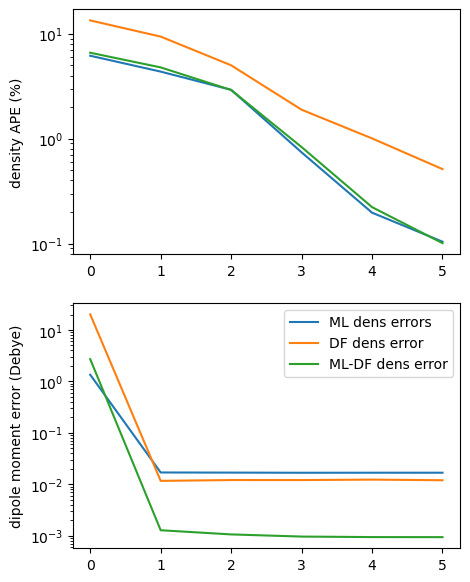

In [15]:
print('all_ml_dens_mae', all_ml_dens_mae.shape)
fig, axs = plt.subplots(2, 1, figsize=(5, 7))
axs[0].plot(np.mean(all_ml_dens_mae, axis=0) * 100, label='ML dens errors')
axs[0].plot(np.mean(all_df_dens_mae, axis=0) * 100, label='DF dens error')
axs[0].plot(np.mean(all_ml_df_dens_mae, axis=0) * 100, label='ML-DF dens error')
axs[1].plot(4.8 * np.mean(all_ml_dpm_errnorm, axis=0), label='ML dens errors')
axs[1].plot(4.8 * np.mean(all_df_dpm_errnorm, axis=0), label='DF dens error')
axs[1].plot(4.8 * np.mean(all_ml_df_dpm_errnorm, axis=0), label='ML-DF dens error')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[0].set_ylim(bottom=0)
axs[1].set_ylim(bottom=0)
axs[0].set_ylabel('density APE (%)')
axs[1].set_ylabel('dipole moment error (Debye)')
plt.legend()
plt.savefig('figures/ethanethiol_dens_errors.png', dpi=300)
plt.show()
# # %%
# fig, axs = plt.subplots(2, 1, figsize=(10, 10))
# axs[0].plot(np.log(np.mean(all_ml_dens_mae, axis=0)), label='ML dens errors')
# axs[0].plot(np.log(np.mean(all_df_dens_mae, axis=0)), label='DF dens error')
# axs[0].plot(np.log(np.mean(all_ml_df_dens_mae, axis=0)), label='ML-DF dens error')
# axs[1].plot(np.log(np.mean(all_ml_dpm_errnorm, axis=0)), label='ML dens errors')
# axs[1].plot(np.log(np.mean(all_df_dpm_errnorm, axis=0)), label='DF dens error')
# axs[1].plot(np.log(np.mean(all_ml_df_dpm_errnorm, axis=0)), label='ML-DF dens error')
# plt.legend()
# plt.show()

In [ ]:
idx = 4
dens_diff_range = np.max(np.abs(np.concatenate([all_ml_dens_errors[idx],
                                                all_df_dens_errors[idx],
                                                all_ml_df_dens_errors[idx]])))
dpm_diff_range = np.max(np.abs(np.concatenate([all_ml_dpm_errors[idx],
                                               all_df_dpm_errors[idx],
                                               all_ml_df_dpm_errors[idx]])))
samp = dataset.get_properties([samps[idx]])

fig, axs = plt.subplots(6, 2, figsize=(10, 10))
center_of_mass = torch.sum(samp['batch_positions'] * samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)\
        / torch.sum(samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)
distance_from_com = torch.norm(samp['coords'] - center_of_mass, dim=2)
distance_from_com_dup = distance_from_com.repeat((1, 3))
dcom = distance_from_com.detach().cpu().numpy().flatten()
dcom_dup = distance_from_com_dup.detach().cpu().numpy().flatten()
for i in range(6):
    print(dcom.shape)
    axs[i, 0].plot(dcom, all_df_dens_errors[idx, i].flatten(), label='DF', marker='.', linestyle='none')
    axs[i, 0].plot(dcom, all_ml_dens_errors[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 0].plot(dcom, all_ml_df_dens_errors[idx, i].flatten(), label='ML-DF', marker='.', linestyle='none')
    axs[i, 0].annotate('DF', xy=(0.1, all_df_dens_mae[idx, i]))
    axs[i, 0].annotate('ML', xy=(0.1, all_ml_dens_mae[idx, i]))
    axs[i, 0].annotate('ML-DF', xy=(0.1, all_ml_df_dens_mae[idx, i]))
    axs[i, 0].set_ylim(-dens_diff_range, dens_diff_range)

    axs[i, 1].plot(dcom_dup, all_df_dpm_errors[idx, i].flatten(), label='DF', marker='.', linestyle='none')
    axs[i, 1].plot(dcom_dup, all_ml_dpm_errors[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 1].plot(dcom_dup, all_ml_df_dpm_errors[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 1].annotate('DF', xy=(0.1, np.sum(all_df_dpm_errors[idx, i].flatten())))
    axs[i, 1].annotate('ML', xy=(0.1, np.sum(all_ml_dpm_errors[idx, i].flatten())))
    axs[i, 1].annotate('ML-DF', xy=(0.1, np.sum(all_ml_df_dpm_errors[idx, i].flatten())))
    axs[i, 1].set_ylim(-dpm_diff_range, dpm_diff_range)
    if i == 0:
        axs[i, 1].legend()
        axs[i, 0].set_title('Pointwise density errors vs true density')
        axs[i, 1].set_title('Pointwise dipole errors vs true density')
# plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML', marker='.', linestyle='none')
# plt.plot(dcom, dpm_ml_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML-DF', marker='.', linestyle='none')
plt.show()

In [ ]:
df_ml_df_dens_diff = all_df_dens_errors - all_ml_df_dens_errors
df_ml_ml_dens_diff = all_ml_dens_errors - all_ml_df_dens_errors

df_ml_df_dpm_diff = all_df_dpm_errors - all_ml_df_dpm_errors
df_ml_ml_dpm_diff = all_ml_dpm_errors - all_ml_df_dpm_errors
dens_diff_range = np.max(np.abs(np.concatenate([df_ml_df_dens_diff, df_ml_ml_dens_diff])))
dpm_diff_range = np.max(np.abs(np.concatenate([df_ml_df_dpm_diff, df_ml_ml_dpm_diff])))
idx = 3
samp = dataset.get_properties([samps[idx]])

fig, axs = plt.subplots(6, 2, figsize=(10, 10))
center_of_mass = torch.sum(samp['batch_positions'] * samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)\
        / torch.sum(samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)
distance_from_com = torch.norm(samp['coords'] - center_of_mass, dim=2)
distance_from_com_dup = distance_from_com.repeat((1, 3))
dcom = distance_from_com.detach().cpu().numpy().flatten()
dcom_dup = distance_from_com_dup.detach().cpu().numpy().flatten()
for i in range(6):
    print(dcom.shape)
    axs[i, 0].plot(dcom, df_ml_df_dens_diff[idx, i].flatten(), label='DF', marker='.', linestyle='none')
    axs[i, 0].plot(dcom, df_ml_ml_dens_diff[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 0].set_ylim(-dens_diff_range, dens_diff_range)

    axs[i, 1].plot(dcom_dup, df_ml_df_dpm_diff[idx, i].flatten(), label='DF', marker='.', linestyle='none')
    axs[i, 1].plot(dcom_dup, df_ml_ml_dpm_diff[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 1].set_ylim(-dpm_diff_range, dpm_diff_range)
    if i == 0:
        axs[i, 1].legend()
        axs[i, 0].set_title('Pointwise density errors vs ML-DF projection')
        axs[i, 1].set_title('Pointwise dipole errors vs ML-DF projection')
# plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML', marker='.', linestyle='none')
# plt.plot(dcom, dpm_ml_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML-DF', marker='.', linestyle='none')
plt.show()

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(7, 21))

for i in range(6):
    axs[i, 0].scatter(df_ml_df_dens_diff[idx, i].flatten(),
                      df_ml_ml_dens_diff[idx, i].flatten())
    axs[i, 0].set_xlabel('DF')
    axs[i, 0].set_ylabel('ML')

    # axs[i, 0].set_xlim(-dens_diff_range, dens_diff_range)
    # axs[i, 0].set_ylim(-dens_diff_range, dens_diff_range)

    axs[i, 1].scatter(df_ml_df_dpm_diff[idx, i].flatten(),
                      df_ml_ml_dpm_diff[idx, i].flatten())
    axs[i, 1].set_xlabel('DF')
    axs[i, 1].set_ylabel('ML')

    # axs[i, 1].set_xlim(-dpm_diff_range, dpm_diff_range)
    # axs[i, 1].set_ylim(-dpm_diff_range, dpm_diff_range)
    # set axis ratio to square
    # axs[i, 0].set_aspect('equal')
    # axs[i, 1].set_aspect('equal')
plt.show()

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(10, 10))
dens_diff_range = np.max(np.abs(np.concatenate([df_ml_ml_dens_diff])))
dpm_diff_range = np.max(np.abs(np.concatenate([df_ml_ml_dpm_diff])))
for i in range(6):
    print(dcom.shape)
    axs[i, 0].plot(dcom, df_ml_ml_dens_diff[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 0].set_ylim(-dens_diff_range, dens_diff_range)

    axs[i, 1].plot(dcom_dup, df_ml_ml_dpm_diff[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 1].set_ylim(-dpm_diff_range, dpm_diff_range)
    if i == 0:
        axs[i, 1].legend()
        axs[i, 0].set_title('Pointwise density errors vs ML-DF projection')
        axs[i, 1].set_title('Pointwise dipole errors vs ML-DF projection')
# plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML', marker='.', linestyle='none')
# plt.plot(dcom, dpm_ml_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML-DF', marker='.', linestyle='none')
plt.show()

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(10, 10))
dens_diff_range = np.max(np.abs(np.concatenate([df_ml_ml_dens_diff])))
dpm_contrib = (samp['density'] * samp['coord_weights']) * distance_from_com
nonzero_idx = (dpm_contrib.flatten() != 0)
print(df_ml_ml_dpm_diff.shape)
print(df_ml_ml_dpm_diff[:, :, :, nonzero_idx][idx].shape)
print(dpm_contrib[:, nonzero_idx].unsqueeze(0).unsqueeze(-1).shape)
dpm_diff_range = np.max(np.abs(df_ml_ml_dpm_diff[:, :, :, nonzero_idx][idx]
                               / dpm_contrib[:, nonzero_idx].unsqueeze(0).unsqueeze(-1).detach().cpu().numpy()))

for i in range(6):
    print(dcom.shape)
    recon_ml_df = reconstruct_dens(samp['density'], all_ml_df_dens_errors[idx, i], samp['coord_weights'])
    axs[i, 0].plot(dcom, df_ml_ml_dens_diff[idx, i].flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 0].set_ylim(-dens_diff_range, dens_diff_range)

    axs[i, 1].plot(dcom_dup, (df_ml_ml_dpm_diff[idx, i] / dpm_contrib.unsqueeze(-1)).flatten(), label='ML', marker='.', linestyle='none')
    axs[i, 1].set_ylim(-dpm_diff_range, dpm_diff_range)
    if i == 0:
        axs[i, 1].legend()
        axs[i, 0].set_title('Pointwise density errors vs ML-DF projection')
        axs[i, 1].set_title('Pointwise dipole errors vs ML-DF projection')
# plt.plot(dcom, dpm_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML', marker='.', linestyle='none')
# plt.plot(dcom, dpm_ml_df_point_err.detach().cpu().numpy().flatten()[dist_com_idx], label='ML-DF', marker='.', linestyle='none')
plt.show()